# DV06 — The `seaborn.objects` Interface

## Why does `seaborn.objects` exist?

In the previous notebook (`01-charts-seaborn.ipynb`) we used the **classic Seaborn API**: functions like `sns.scatterplot()`, `sns.barplot()`, `sns.lineplot()`, and `sns.FacetGrid()`. That API is very productive for single-layer charts and quick exploratory analysis. But it has structural limits that appear as soon as a chart becomes more complex:

- **Layering is awkward.** If you want raw points plus a fitted line plus a confidence band, you must make three separate function calls, managing the same axes object manually and repeating the data argument each time.
- **Mark types are locked to function names.** Changing from a bar to a dot, or from a line to an area, means rewriting everything — the function name, keyword arguments, and any keyword that differs between functions.
- **Statistical transformations are hidden.** `sns.barplot()` computes a mean internally. There is no way to see that step in the code or to replace it with a different aggregation without reading the documentation carefully.
- **Positional adjustments are implicit defaults.** Dodging in `sns.barplot(hue=...)` just happens. You cannot easily swap it for stacking, jittering, or no adjustment at all without switching functions.

`seaborn.objects` (also written `so`) was introduced in Seaborn 0.12 specifically to address these limits.

## What is the design philosophy?

`seaborn.objects` is a **grammar of graphics** interface. The idea comes from Leland Wilkinson's *The Grammar of Graphics* (1999) and is most famously implemented in R's **ggplot2** and in the web-based **Vega-Lite** specification language.

The core idea is that every chart is a **pipeline** assembled from independent, composable pieces:

```
data → [transform] → mark → [scale] → [facet]
```

In `seaborn.objects`, this pipeline is expressed explicitly in code:

- `so.Plot(data, mappings)` — declares the data source and which variable maps to which visual property
- `.add(mark, stat, move)` — adds one layer: a visible shape, an optional statistical transformation before drawing, and an optional positional adjustment after
- `.scale(...)` — controls how data values map to visual values (axis scale, color scale, size scale)
- `.facet(...)` — repeats the entire plot logic across panels of a grid
- `.label(...)` — sets axis labels, legend labels, and the figure title
- `.show()` — renders the assembled specification

The user assembles the pieces; Seaborn handles the rendering. This separation means that swapping a bar for a dot is one word change, and adding a new layer is one new `.add()` call.

## What is the practical potential?

Once a chart is written as a pipeline, several things that are difficult in the classic API become straightforward:

- **Multi-layer composition:** stack as many `.add()` calls as needed; each layer shares the same data mapping unless overridden
- **Mark swapping:** replace `so.Bar()` with `so.Dot()` in one place and every other aspect of the chart stays unchanged
- **Explicit transformations:** `so.Agg()`, `so.Hist()`, `so.Est()`, and `so.PolyFit()` are visible steps in the pipeline, not hidden behavior inside a function
- **Declarative faceting:** `.facet(col='species')` applies the entire plot logic to every species panel without any loop or manual subplot management

## Learning goals

- understand what `seaborn.objects` is and why Seaborn introduced it
- learn the basic grammar of `Plot`, `Mark`, `Stat`, and `Move`
- see where the objects interface is more composable than the classic Seaborn API
- decide when the extra verbosity is worth the flexibility

This notebook is an **advanced extension** to the classic Seaborn notebook. It does not replace the standard API. Instead, it shows what becomes possible when Seaborn plotting is expressed as an explicit composition of layers and transformations.

## Notebook roadmap

1. Build a plot from a `Plot` object and a `Mark`
2. Map graphical properties directly from data
3. Layer marks and fitted transformations explicitly
4. Separate statistical transformation from graphical representation
5. Make positional adjustments such as dodging part of the grammar
6. Keep grouping explicit for lines
7. Scale the same logic to a faceted figure

## Status of the Interface

According to the current Seaborn documentation, the objects interface was introduced in version `0.12` as a **new, more consistent, and more composable plotting system**. The same documentation also says something students should know early: it is still **experimental and incomplete**, even though it is stable enough for serious use.

That combination explains how this notebook should be read.

- This is **not** the default beginner path through Seaborn.
- This is **not** a replacement for the classic API.
- This **is** a useful next step once students already understand standard Seaborn charts and want a more explicit plotting grammar.

The main promise of `seaborn.objects` is that it separates parts of a chart that the classic API often bundles together. Instead of calling one convenience function and letting the function hide the construction, students can see more clearly:

- what the data mappings are
- what graphical mark is being drawn
- what statistical transformation happens before drawing
- what positional adjustment happens after that transformation

To make the advantage concrete: in `01-charts-seaborn.ipynb`, adding a trend line to a scatter plot required calling `sns.regplot()` on the same axes object — a second function call with its own defaults that the first function knew nothing about. In `seaborn.objects`, that same composition is a second `.add()` call on the same `Plot()` object. The data mapping is declared once; both layers share it automatically.

## A Short Vocabulary for `seaborn.objects`

Before we start using the interface, we should name the main concepts explicitly. The grammar of graphics divides a chart into independent building blocks. `seaborn.objects` maps those blocks to specific Python classes.

**Plot**

`so.Plot(data, x=..., y=..., color=..., ...)` is the root of every chart. It declares the dataset and the *variable-to-property mappings* — which column drives which visual channel. Every subsequent `.add()` call inherits these mappings unless explicitly overridden.

**Mark**

A mark is the visible geometry drawn for each data unit (or each aggregated group). Available marks include:

| Class | What it draws |
|---|---|
| `so.Dot()` | One point per row |
| `so.Dots()` | Like Dot but renders better for dense overplotting |
| `so.Line()` | A connected line through sorted x values |
| `so.Bar()` | One rectangle per group (categorical axis) |
| `so.Bars()` | One rectangle per bin (continuous axis, e.g. histogram) |
| `so.Area()` | A filled region under a line |
| `so.Band()` | A filled interval between two y values (e.g. confidence band) |

Marks accept *fixed* properties (e.g. `so.Dot(color='steelblue', alpha=0.6)`) as keyword arguments. *Mapped* properties come from the `Plot()` specification instead.

**Stat**

A stat is a data transformation that runs before drawing. It reduces many rows to fewer summary values, or transforms the data in some other way:

| Class | What it computes |
|---|---|
| `so.Agg(func='mean')` | One summary value per group (default: mean) |
| `so.Hist()` | Bin counts or densities for a continuous variable |
| `so.Est()` | A central tendency estimate with a confidence interval |
| `so.PolyFit(order=1)` | A polynomial regression line through the data |

**Move**

A move is a positional adjustment applied after the stat. It solves overlap problems:

| Class | What it does |
|---|---|
| `so.Dodge()` | Shifts groups sideways so they sit side by side |
| `so.Stack()` | Stacks groups on top of each other |
| `so.Jitter()` | Adds random noise to positions to reduce overplotting |

**The assembly pattern**

A complete specification reads like a sentence: start with a `Plot`, add one or more layers each combining a `Mark` with an optional `Stat` and optional `Move`, then label and facet if needed.

```python
(
    so.Plot(data, x='col_a', y='col_b', color='col_c')
    .add(so.Bar(), so.Agg(), so.Dodge())   # layer 1: grouped bars
    .add(so.Dot(), so.Agg(), so.Dodge())   # layer 2: mean dots on top
    .label(title='...', x='...', y='...')
    .facet(col='col_d')
    .show()
)
```

When a new concept appears in the code below, the most useful question to ask is: **is this a mark, a stat, or a move?** That one check makes the entire grammar easier to read.

## How to Read the Code in This Notebook

The objects interface is **declarative**. That means the code is mainly describing *what the plot should be*, not drawing it step by step the way a Matplotlib script often does.

A few reading habits help:

- `.add(...)` means "add one layer to the plot"
- `.label(...)` means "set titles, axis labels, and legend labels"
- `.scale(...)` means "control how a data dimension maps to a visual dimension"
- `.facet(...)` means "repeat the same plot logic across panels"
- `.show()` forces the plot to render in a notebook or script

One subtle but important point from the Seaborn docs is that `Plot` methods return a **new plot specification** rather than modifying the old one in place. So students should read each chained method as *refining* the plot description, not executing a side effect. The chart is only rendered when `.show()` is called.

This means the entire specification is just a Python object until `.show()`. You can build it up in steps, store it in a variable, and reuse it:

```python
base = so.Plot(pen_clean, x='bill_length_mm', y='flipper_length_mm')
scatter = base.add(so.Dot())
scatter_with_trend = base.add(so.Dot()).add(so.Line(), so.PolyFit(order=1))
# base is unchanged — both scatter and scatter_with_trend are independent specs
```

This notebook keeps comparing the objects interface with the classic API. The point is not to prove that one is always better. The point is to learn what the objects interface makes more explicit and therefore more controllable.

## When This Interface Is Useful

Students should not leave this notebook thinking that `seaborn.objects` must replace the classic API everywhere.

A reasonable workflow is:

- use the **classic API** when there is already a clean Seaborn function that matches the chart you need and you do not need to layer, transform, or facet beyond its built-in options
- use **`seaborn.objects`** when layering, transformation, grouping, or positioning logic needs to be more explicit

The main advantage of `seaborn.objects` is not brevity — classic Seaborn is usually shorter. The main advantage is **composability**: the ability to combine pieces without rewriting everything each time.

That also means the main cost is real:

- the code is usually more verbose
- students must learn more concepts (marks, stats, moves) before they can be productive

For that reason, this notebook treats `seaborn.objects` as an advanced extension, not as the entry point.

To make the trade-off concrete, here is the same grouped bar chart written in both interfaces:

```python
# Classic Seaborn — concise, but dodging and aggregation are hidden defaults
sns.barplot(data=pen_clean, x='species', y='body_mass_g', hue='sex')

# seaborn.objects — more code, but every decision is visible
(
    so.Plot(pen_clean, x='species', y='body_mass_g', color='sex')
    .add(so.Bar(), so.Agg(), so.Dodge())
    .show()
)
```

The objects version explicitly shows that:
1. `so.Bar()` is the mark (the shape drawn)
2. `so.Agg()` is the statistical step (compute one mean per group)
3. `so.Dodge()` is the positional adjustment (move groups side by side)

Classic Seaborn does all three silently. The objects interface makes each decision a named, swappable component.

In [11]:
import sys
from pathlib import Path

tutorials_dir = Path.cwd().resolve().parent
if str(tutorials_dir) not in sys.path:
    sys.path.insert(0, str(tutorials_dir))

from dataviz_utils import *
import seaborn as sns
import seaborn.objects as so

set_seeds()

sns.set_theme(style='whitegrid', palette=CATEGORICAL_PALETTE)
FONT = apply_teaching_rc(font_base=12.0, figure_dpi=170, savefig_dpi=360, grid=False)
FIG = make_figure_size_scale()

gap = load_gapminder()
pen_clean = load_penguins()
gap_2007 = gap[gap['year'] == 2007].copy()
palette = {species: CATEGORICAL_PALETTE[i] for i, species in enumerate(['Adelie', 'Chinstrap', 'Gentoo'])}

## A Reusable Reading Pattern

Almost every example in this notebook follows the same four-part recipe. Reading this pattern once before the examples makes the rest of the notebook much easier to follow.

```
so.Plot(data, mappings)          ← step 1: declare what the data is and what maps where
    .add(mark, [stat], [move])   ← step 2: declare what to draw, how to transform it, how to position it
    .add(mark, [stat], [move])   ← optional: add more layers
    .label(title=..., x=..., y=..., color=...)   ← step 3: name things
    .facet(col=..., row=...)     ← optional: repeat across panels
    .show()                      ← step 4: render
```

When a new concept appears, the safest student question is: **is this a mark, a stat, or a move?** That simple check makes the grammar much easier to read.

A second useful question is: **is this argument inside `Plot()` or inside the mark?** Arguments inside `Plot()` are *data mappings* (they connect a data column to a visual property). Arguments inside a mark like `so.Dot(color='gray')` are *fixed properties* (they set a visual property to a constant, ignoring the data). This distinction matters because it determines whether the property appears in the legend.

## 1. Start with a minimal scatterplot

**Problem with classic Seaborn:** `sns.scatterplot(data=pen_clean, x='bill_length_mm', y='flipper_length_mm')` is perfectly fine as a single call. But when you want to add a trend line, you must call a *different* function (`sns.regplot()`) on the same axes object. The data argument must be repeated, the mark defaults may differ, and the two functions have no shared vocabulary.

**How SO solves it:** the `Plot()` object holds the data mapping once. Every `.add()` call shares that mapping. Adding a second layer is just a second `.add()` — no duplicate arguments, no axes management.

**SO classes used in this section:** `so.Plot`, `so.Dot`

---

**Use when:** students need the smallest possible example of the objects grammar.

**Why this design:** a scatterplot lets us introduce the two most important ideas first:

- `so.Plot(...)` defines the data mapping
- `so.Dot()` defines the visible mark

In the classic API, this would be one call to `sns.scatterplot(...)`. In the objects interface, we separate the **plot definition** from the **mark** that draws each observation. This separation is what makes layering, mark-swapping, and faceting possible later.

Before reading the code, notice the left-to-right build order:

1. start with the data and mappings
2. add one mark
3. label the figure
4. render it

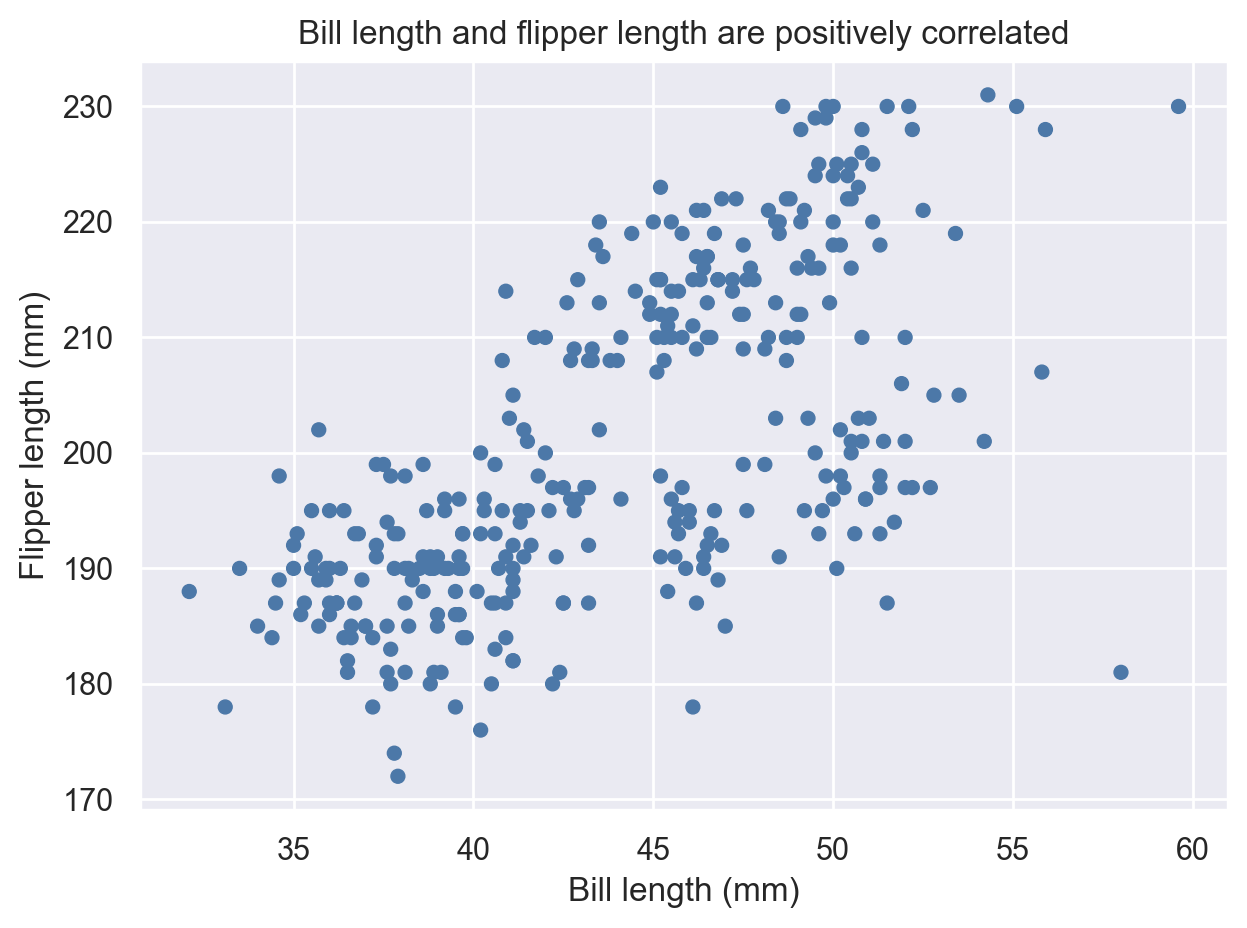

In [12]:
(
    # so.Plot declares the data source (pen_clean) and the variable-to-axis mappings.
    # Nothing is drawn yet — this is just a specification object.
    so.Plot(pen_clean, x='bill_length_mm', y='flipper_length_mm')

    # .add() introduces the first (and only) layer.
    # so.Dot() is the mark: it draws one visible point per row in the dataset.
    # The arguments inside so.Dot() are FIXED properties — they apply to every dot equally.
    # Contrast: if color were in Plot() instead, it would be MAPPED from a data column.
    .add(so.Dot(pointsize=5, color=DV_PALETTE['blue']))

    # .label() sets the axis labels and the figure title.
    # Titles should be data statements, not chart-type labels.
    .label(
        title='Bill length and flipper length are positively correlated',
        x='Bill length (mm)',
        y='Flipper length (mm)',
    )

    # .show() triggers the actual rendering.
    # Until this call, the entire chain above is just a description of a chart.
    .show()
)

**Takeaway:** the first important idea is the separation between **data mapping** (declared in `Plot()`) and **graphical mark** (declared in `.add()`). The objects interface starts by making that separation explicit.

Classic Seaborn bundles the two together in the function name: `sns.scatterplot()` means "map these columns *and* draw points." In the objects interface, these are independent decisions. That independence is the foundation for everything that follows in this notebook.

**When to use this pattern:** any time you start building a new chart in SO, begin with the minimal `Plot + Mark` form shown here. Add stats, moves, and additional layers only as needed.

## 2. Map visual properties directly

**Problem with classic Seaborn:** the classic API uses inconsistent keyword names across functions. `hue=` maps color in most functions, but `c=` does the same in Matplotlib scatter. `size=` maps point size in `sns.scatterplot()` but is a fixed pixel value in most Matplotlib calls. These inconsistencies force students to check the documentation for each function separately.

**How SO solves it:** in `seaborn.objects`, the keyword names in `Plot()` are the actual graphical property names — `color=`, `pointsize=`, `alpha=`, `linewidth=`. This uniformity means students can learn the property names once and apply them across all mark types.

**SO classes used in this section:** `so.Plot` (with multiple mapped properties), `so.Dot` (with fixed properties)

---

**Use when:** one chart needs additional graphical properties such as color or point size to be mapped from the data.

**Why this design:** this section introduces the most important distinction in the objects interface:

- passing a value inside `so.Dot(alpha=0.75)` **sets** a property to a constant — every dot gets the same alpha regardless of data
- passing a column name in `so.Plot(color='species')` **maps** a property from the data — each row gets a color based on its species value

That difference determines whether a property appears in the legend and whether it varies across the data. It also explains why some arguments live in `Plot(...)` while others live inside the mark class.

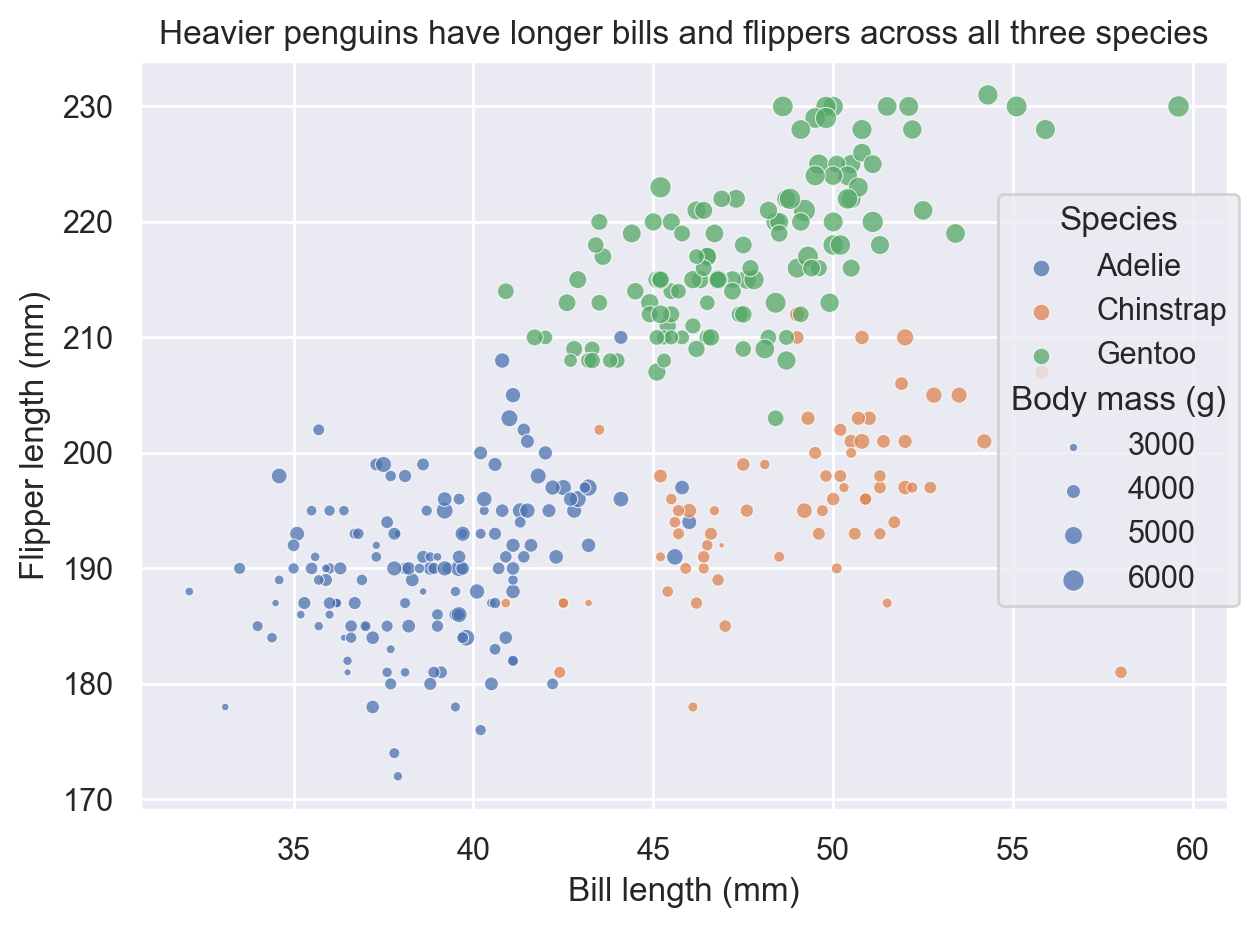

In [13]:
(
    so.Plot(
        pen_clean,
        x='bill_length_mm',
        y='flipper_length_mm',
        # color and pointsize are MAPPED: each row gets a different value based on data.
        # Because they are in Plot(), Seaborn will automatically add them to the legend.
        color='species',
        pointsize='body_mass_g',
    )
    # alpha, edgecolor, and edgewidth are FIXED: every dot gets the same values.
    # They live inside so.Dot() because they are not driven by any data column.
    # In classic Seaborn, alpha= is also a keyword of sns.scatterplot(), but edgecolor
    # and edgewidth would require a separate call to ax.collections[0].set_...()
    .add(so.Dot(alpha=0.75, edgecolor='white', edgewidth=0.4))
    # .label() names both the axes and the legend entries.
    # 'color' and 'pointsize' here refer to the mapped properties declared in Plot().
    .label(
        title='Heavier penguins have longer bills and flippers across all three species',
        x='Bill length (mm)',
        y='Flipper length (mm)',
        color='Species',
        pointsize='Body mass (g)',
    )
    .show()
)

**Takeaway:** the objects interface uses a **uniform grammar for mapped properties** — the keyword is the actual property name (`color=`, `pointsize=`), not a function-specific alias (`hue=`, `size=`). This uniformity means the same vocabulary works across `so.Dot`, `so.Bar`, `so.Line`, and every other mark.

Classic Seaborn equivalent (for reference):
```python
# Classic API uses hue= instead of color=, size= instead of pointsize=
sns.scatterplot(data=pen_clean, x='bill_length_mm', y='flipper_length_mm',
                hue='species', size='body_mass_g', alpha=0.75)
# edgecolor styling requires a lower-level Matplotlib call afterward
```

**When to use this pattern:** any time a single layer chart needs two or more visual properties mapped from data columns. The `Plot()` declaration keeps all mappings in one place, making the chart specification self-documenting.

## 3. Layer marks explicitly

**Problem with classic Seaborn:** adding a fitted trend line to a scatter plot requires calling a second function (`sns.regplot()` or `sns.lmplot()`) on the same Matplotlib axes. The data argument must be repeated. The two functions have different defaults for alpha, line color, and confidence intervals. The code structure no longer reads as a single chart — it reads as two separate chart calls that happen to share an axes object.

**How SO solves it:** every `.add()` call shares the data mapping declared in `Plot()`. Adding a second layer is syntactically identical to adding the first one. The order of `.add()` calls determines the rendering order (later layers appear on top).

**SO classes used in this section:** `so.Dots` (mark for raw observations), `so.Line` (mark for the fitted line), `so.PolyFit` (stat that computes a polynomial regression before drawing)

---

**Use when:** one plot needs several visible layers, such as raw observations plus a fitted trend.

**Why this design:** layering is the main structural advantage of `seaborn.objects`. Each call to `.add(...)` contributes one more layer to the final figure without any axes management.

`so.PolyFit(order=1)` is a **stat**: it transforms the raw data into a set of fitted y-values along the x-range before the `Line` mark draws them. The order parameter controls polynomial degree — `order=1` is a straight line (linear regression), `order=2` would be a curve.

The important step-by-step idea is:

1. add the raw dots (one mark per observation)
2. add a second layer for the fitted relationship (stat transforms, then line mark draws)
3. both layers share the same x/y mapping and the same axis limits

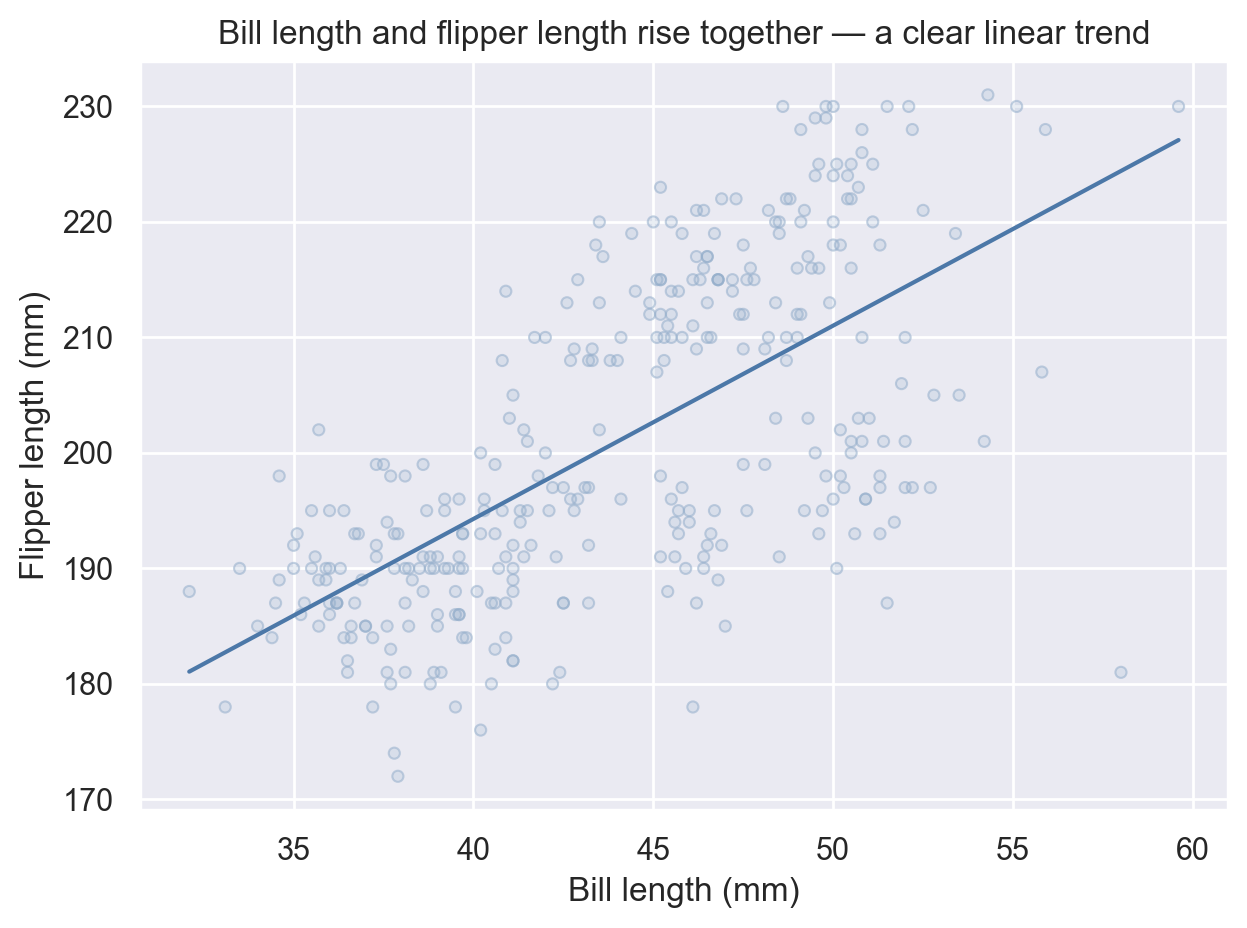

In [14]:
(
    # The data mapping is declared once in Plot() and shared by all layers below.
    so.Plot(pen_clean, x='bill_length_mm', y='flipper_length_mm')

    # LAYER 1: raw observations.
    # so.Dots is the mark (similar to so.Dot but handles dense point clouds better).
    # The color and alpha are FIXED — every dot looks the same.
    # lighten_color() blends the base blue toward white to reduce visual weight.
    .add(so.Dots(color=lighten_color(DV_PALETTE['blue'], 0.60), alpha=0.55))

    # LAYER 2: fitted linear trend.
    # so.Line is the mark — it draws a line.
    # so.PolyFit(order=1) is the STAT — it runs a linear regression on the raw data
    # and produces the fitted (x, y) values that the Line mark will draw.
    # The stat runs BEFORE the mark draws. This is the stat → mark pipeline in action.
    # order=1 means linear (straight line); increase it for polynomial curves.
    .add(so.Line(color=DV_PALETTE['blue']), so.PolyFit(order=1))

    .label(
        title='Bill length and flipper length rise together — a clear linear trend',
        x='Bill length (mm)',
        y='Flipper length (mm)',
    )
    .show()
)

**Takeaway:** two `.add()` calls compose two layers without re-declaring data, repeating axis arguments, or managing an axes object. This is the core composability pattern of `seaborn.objects`.

Classic Seaborn equivalent (for reference — notice the repeated data argument and separate function call):
```python
ax = sns.scatterplot(data=pen_clean, x='bill_length_mm', y='flipper_length_mm',
                     color=lighten_color(DV_PALETTE['blue'], 0.60), alpha=0.55)
sns.regplot(data=pen_clean, x='bill_length_mm', y='flipper_length_mm',
            ax=ax, scatter=False, color=DV_PALETTE['blue'], ci=None)
```

The objects version keeps both layers inside one specification. Adding a third layer (e.g. a confidence band with `so.Band()` and `so.Est()`) is another `.add()` call, not a third function.

**When to use this pattern:** any time you want to show both the raw data and a summary or fitted transformation on the same axes. The two-layer pattern is the most common use case for `seaborn.objects` in practice.

## 4. Build bars from a statistical transformation

**Problem with classic Seaborn:** `sns.barplot()` computes a mean (or another estimator) and draws bars in a single call. This is convenient but opaque. Students who want to understand what the function is doing have to read the documentation to discover that the default `estimator` is `np.mean`. Swapping the aggregation function (e.g. to median or sum) requires passing an `estimator=` keyword that looks nothing like the drawing step.

**How SO solves it:** in the objects interface, the aggregation is a **stat** (`so.Agg()`) and the drawing is a **mark** (`so.Bar()`). They are separate arguments passed to `.add()`. Switching from mean to median is `so.Agg('median')` — one word, no change to the mark. Switching from a bar to a dot is changing the mark class — no change to the stat.

**SO classes used in this section:** `so.Bar` (mark: one rectangle per group), `so.Agg` (stat: aggregates many rows to one summary value per group)

---

**Use when:** the chart needs one summary value per category rather than one mark per row.

**Why this design:** this is where the objects interface becomes especially educational. A bar is just a **mark** — a rectangle. The summarization step is a separate **statistical transformation**. Keeping them separate makes it easy to answer the question that every bar chart implicitly raises: "what value does each bar represent?"

`so.Agg()` aggregates along the value axis. By default it uses the **mean**, making this example directly comparable to `sns.barplot(...)` with default settings. Students can verify this by reading the `.add()` call — the stat is visible in the code.

Students often benefit from reading this expression as three questions:

- what is the category on the x-axis?
- what value is being summarized on the y-axis?
- what statistic (`so.Agg()`) turns many rows into one bar?

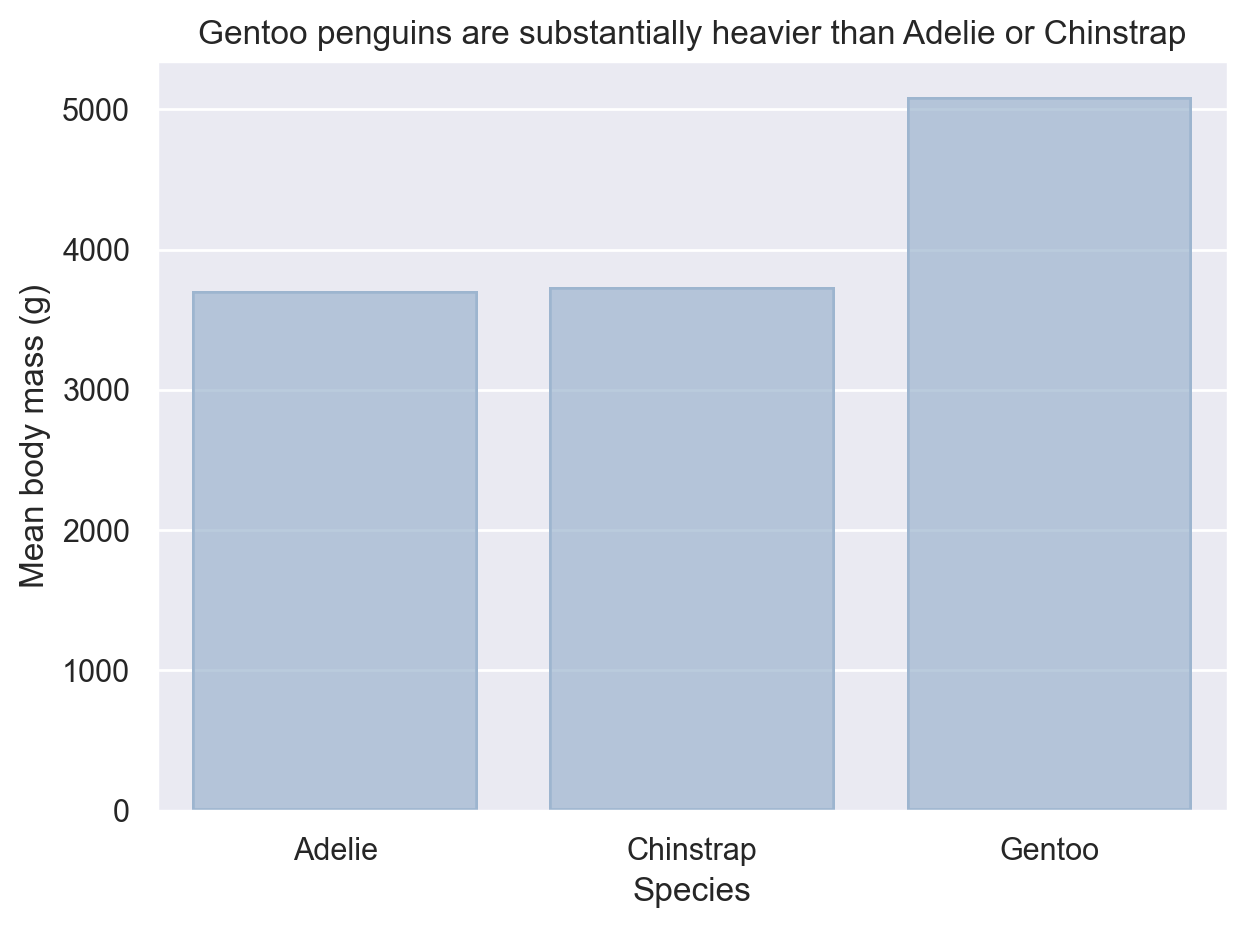

In [15]:
(
    # Plot() declares the data and mappings as usual.
    # x is categorical (species), y is the column to be aggregated (body_mass_g).
    so.Plot(pen_clean, x='species', y='body_mass_g')

    # .add() now takes two arguments: a mark AND a stat.
    # so.Bar() is the MARK — it draws one rectangle per group.
    # so.Agg() is the STAT — it collapses all rows for each species into one mean value.
    # The stat runs FIRST. The mark draws AFTER.
    # Equivalent classic call (hidden aggregation): sns.barplot(data=pen_clean, x='species', y='body_mass_g')
    # To change the aggregation to median: replace so.Agg() with so.Agg('median') — no other change needed.
    .add(so.Bar(color=lighten_color(DV_PALETTE['blue'], 0.55)), so.Agg())

    .label(
        title='Gentoo penguins are substantially heavier than Adelie or Chinstrap',
        x='Species',
        y='Mean body mass (g)',
    )
    .show()
)

**Takeaway:** `so.Agg()` makes the aggregation step **visible in the code**. Classic `sns.barplot()` hides the distinction between the bar as a shape and the mean as a statistical summary. The objects interface separates those two decisions cleanly.

The practical benefit: if a collaborator reads `sns.barplot()`, they must know the default `estimator` to understand what value each bar represents. If they read `.add(so.Bar(), so.Agg())`, the answer is in the code.

Swapping the statistic is also easier:
```python
.add(so.Bar(), so.Agg())           # mean (default)
.add(so.Bar(), so.Agg('median'))   # median — one word change
.add(so.Bar(), so.Agg('sum'))      # sum
```

**When to use this pattern:** any categorical summary chart where the aggregation function matters for interpretation. Showing the stat explicitly makes the chart more honest and the code more readable.

## 5. Make grouped comparisons explicit with `Dodge`

**Problem with classic Seaborn:** `sns.barplot(hue='sex')` automatically dodges the bars sideways. This is convenient for a quick chart, but there is no way to tell from reading the code that dodging happened. If you want to stack instead of dodge, or jitter instead of dodge, you must switch to a different function. The positional adjustment is baked into the function choice.

**How SO solves it:** `so.Dodge()` is a **move** — a named, swappable component. Replacing `so.Dodge()` with `so.Stack()` stacks the bars instead. Removing it entirely causes the bars to overlap. The positional adjustment is a visible, explicit decision.

**SO classes used in this section:** `so.Bar` (mark), `so.Agg` (stat), `so.Dodge` (move: shifts groups sideways)

---

**Use when:** several groups occupy the same categorical position and we want them to sit side by side instead of overlapping.

**Why this design:** in the classic API, grouped bars are convenient because dodging happens automatically once `hue` is assigned. In the objects interface, that positional adjustment is explicit.

`so.Dodge()` is a **Move**: it changes the positions of marks *after* the data mapping and *after* any aggregation. That explicitness is one of the main advantages of the objects interface: the code tells us not only **what** is drawn, but also **how** the grouped bars were separated in space.

To understand why the order of arguments inside `.add()` matters: Seaborn applies them in the order `stat → move → mark`. So the data is aggregated first, then dodged, then drawn as bars. Changing the order would change the result.

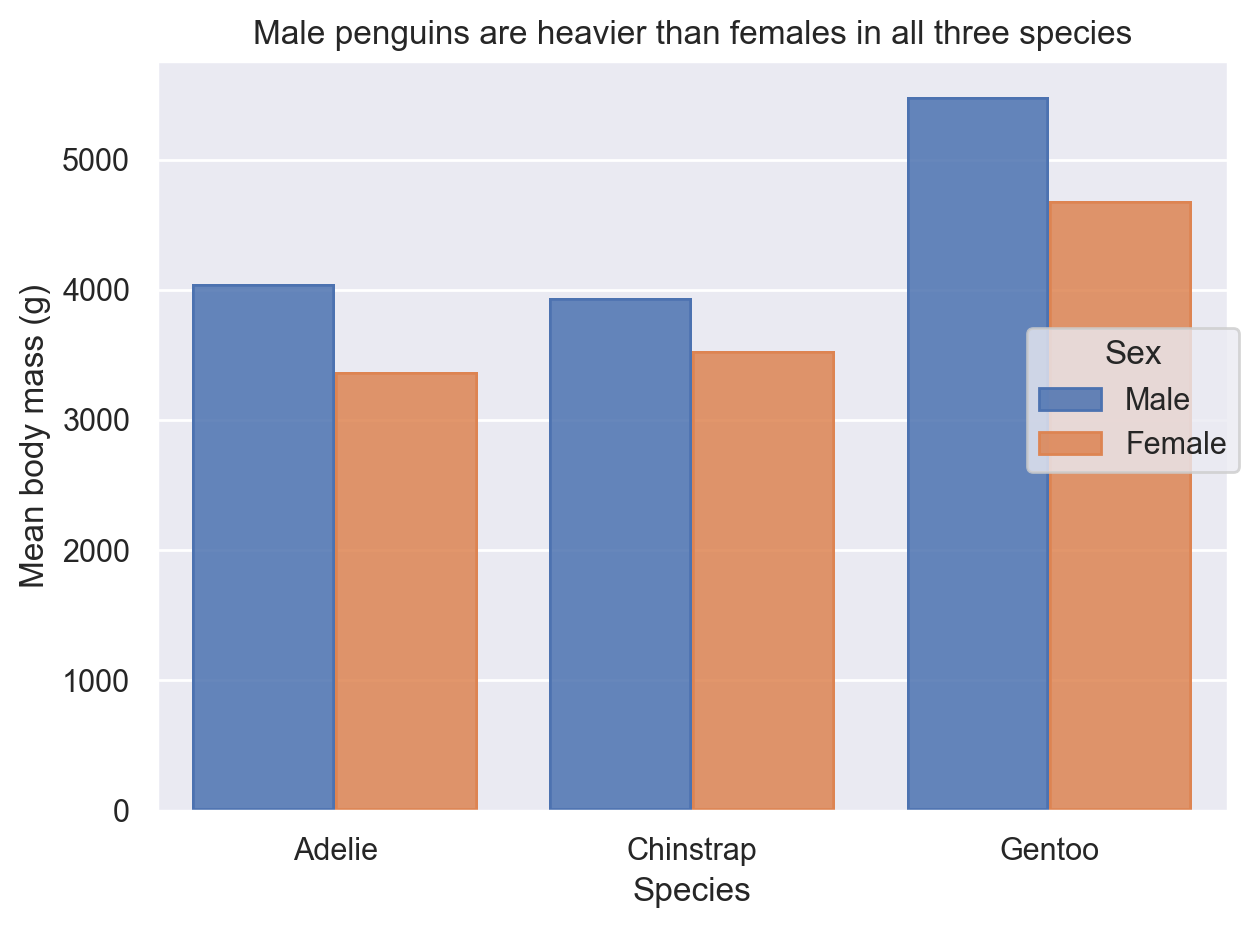

In [16]:
(
    # color='sex' in Plot() is a MAPPED property: it splits the data into male/female groups
    # and automatically assigns a different color to each group.
    # Because it's in Plot(), Seaborn will add it to the legend.
    so.Plot(pen_clean, x='species', y='body_mass_g', color='sex')

    # Three things happen inside this single .add() call, in this order:
    #   1. so.Agg() (STAT): collapses all rows per species/sex group into one mean value
    #   2. so.Dodge() (MOVE): shifts the male and female bars sideways so they don't overlap
    #   3. so.Bar() (MARK): draws the resulting rectangles
    # Removing so.Dodge() would stack the groups at the same x position (overlapping).
    # Replacing so.Dodge() with so.Stack() would stack them vertically instead.
    .add(so.Bar(alpha=0.85), so.Agg(), so.Dodge())

    .label(
        title='Male penguins are heavier than females in all three species',
        x='Species',
        y='Mean body mass (g)',
        color='Sex',
    )
    .show()
)

**Takeaway:** `so.Dodge()` makes the spatial adjustment **part of the grammar** instead of a hidden default. Classic `sns.barplot(hue='sex')` always dodges without showing that decision in the code. In `seaborn.objects`, swapping the positional adjustment is a one-word change:

```python
.add(so.Bar(), so.Agg(), so.Dodge())   # side by side (current)
.add(so.Bar(), so.Agg(), so.Stack())   # stacked vertically
.add(so.Bar(), so.Agg())               # overlapping (no move)
```

Classic Seaborn equivalent (for reference):
```python
# Classic API — dodge is automatic; stack would require a different function
sns.barplot(data=pen_clean, x='species', y='body_mass_g', hue='sex')
```

**When to use this pattern:** any grouped categorical chart where the spatial arrangement of groups is a design decision worth making explicit — especially if you want to compare dodged vs. stacked representations or add a Jitter move on top of a strip plot.

## 6. Group line data without relying on a special case

**Problem with classic Seaborn:** `sns.lineplot()` has a `hue=` parameter for grouping, but it also has an `units=` parameter for when groups should be drawn but not color-coded. The function handles many grouping cases through keyword combinations that are not easy to discover or remember. Moving from a line chart to a point-plus-line chart means calling `sns.lineplot()` and then overlaying `sns.scatterplot()` on the same axes — two different functions with different defaults.

**How SO solves it:** the grouping logic in `seaborn.objects` is always the same: any property mapped from data (like `color=`) defines the groups for marks that connect observations. A point-plus-line chart is just two `.add()` calls with different marks. No new function names to learn.

**SO classes used in this section:** `so.Line` (mark: connects observations in x-order within each group), `so.Dot` (mark: draws a point at each observed time step)

---

**Use when:** a line chart connects repeated observations belonging to several groups, and we also want to mark the individual observed time points.

**Why this design:** when a mark connects observations, grouping matters. The objects interface keeps that grouping logic explicit through mapped properties such as `color=` or `group=`. This section is useful because it shows that the grammar stays stable even when the visible mark changes from dots to connected lines.

Students do not need to learn a brand-new plotting idea for time series. They keep the same recipe and simply change the mark. The two-layer pattern from Section 3 (raw data + transformation) applies here too: Layer 1 draws connected lines, Layer 2 draws the observation points on top.

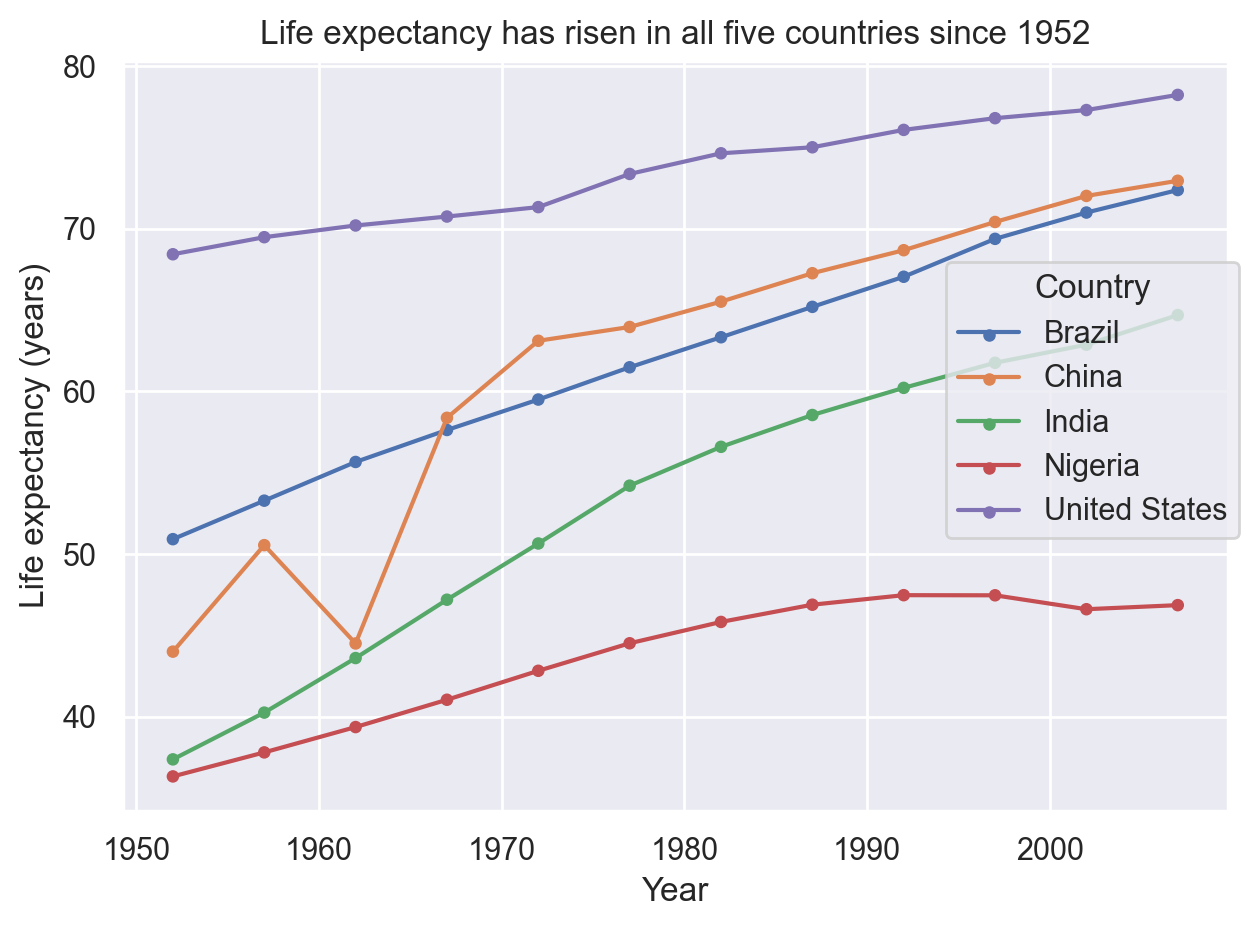

In [17]:
selected = gap[gap['country'].isin(['China', 'India', 'United States', 'Brazil', 'Nigeria'])].copy()

(
    # color='country' is a MAPPED property that defines both the color coding and the groups.
    # so.Line connects observations within each color group in x-order (sorted by year).
    # Without color='country', so.Line would try to connect ALL rows in one line,
    # producing a tangled chart that jumps between countries.
    so.Plot(selected, x='year', y='lifeExp', color='country')

    # LAYER 1: so.Line connects the observations for each country in x-order.
    # This is the equivalent of sns.lineplot(data=selected, x='year', y='lifeExp', hue='country')
    # but expressed as a composable layer.
    .add(so.Line())

    # LAYER 2: so.Dot adds a visible point at each observed year.
    # This second layer uses the same color mapping as Layer 1 automatically.
    # In classic Seaborn, this would require a second call to sns.scatterplot() on the same axes.
    .add(so.Dot(pointsize=4))

    .label(
        title='Life expectancy has risen in all five countries since 1952',
        x='Year',
        y='Life expectancy (years)',
        color='Country',
    )
    .show()
)

**Takeaway:** the objects interface does not need a special "lineplot mindset." The grammar is stable: the same `Plot + add` structure works for scatter, bars, lines, and point-plus-line charts. Only the mark class changes. The same `color=` mapping that splits groups for bars also defines line groups automatically.

Classic Seaborn equivalent (for reference — notice the two separate function calls):
```python
ax = sns.lineplot(data=selected, x='year', y='lifeExp', hue='country')
sns.scatterplot(data=selected, x='year', y='lifeExp', hue='country',
                ax=ax, legend=False)  # suppress duplicate legend
```

**When to use this pattern:** any time series chart where you want to show both the connecting lines and the individual observed data points. The two-layer SO version is cleaner because both layers share the color mapping without any `legend=False` workaround.

## 7. Scale up to a faceted comparison

**Problem with classic Seaborn:** faceting in the classic API requires `sns.FacetGrid()` — a separate object with a different interface that must be combined with `.map()` or `.map_dataframe()`. The mark logic (what to draw) and the panel logic (how many panels) are specified in different places, using different syntax. Adding a second layer to each panel requires a second `.map()` call.

**How SO solves it:** `.facet(col='species')` is just another method on the same `Plot()` object. The entire mark logic from the single-panel version is preserved unchanged. Seaborn replicates it automatically into each panel.

**SO classes used in this section:** `so.Bars` (mark: histogram rectangles on a continuous axis), `so.Hist` (stat: bins the data and counts observations per bin), `.facet()` (repeats the plot logic across panels)

---

**Use when:** the same plot logic should be repeated across several subsets of the data to compare distributions or trends across groups.

**Why this design:** faceting is one of the clearest demonstrations of the composability advantage. The plot specification is written once; `.facet()` multiplies it across panels without any loop or manual subplot management.

One detail from the Seaborn docs matters here: for a histogram on a continuous axis, `so.Bars()` (plural) is the correct mark to pair with `so.Hist()`. `so.Bar()` (singular) is for categorical axes where one bar = one category. `so.Bars()` (plural) is for continuous axes where one bar = one bin.

This is also a good final example because it brings the grammar together:

- `Plot(...)` defines the shared mapping
- `Bars + Hist` define the histogram construction
- `.facet(...)` repeats the same logic across panels without any loop

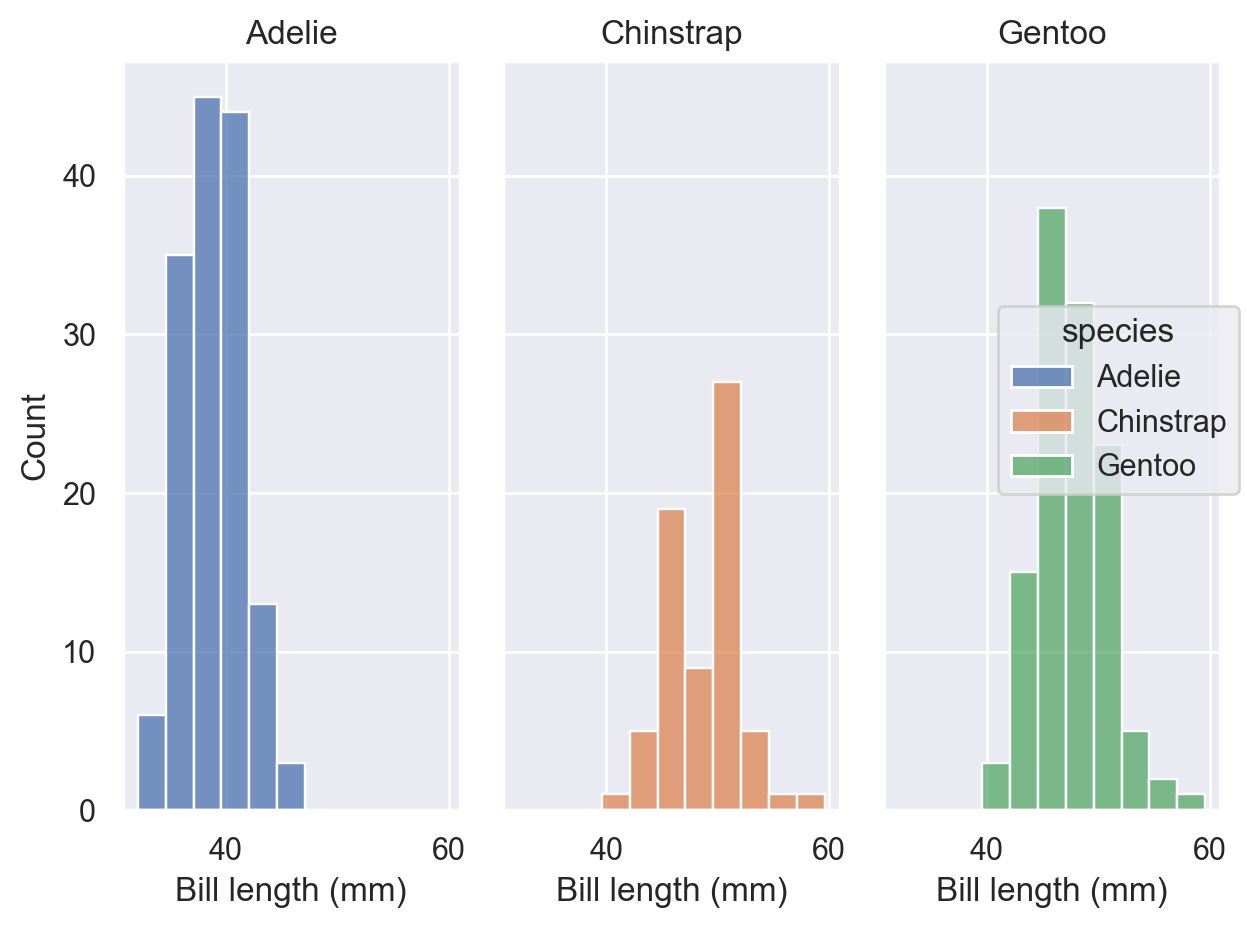

In [23]:
(
    # color='species' in Plot() maps species to a color channel.
    # This also implicitly groups the data for marks that need grouping (like so.Line).
    so.Plot(pen_clean, x='bill_length_mm', color='species')

    # so.Hist() is the STAT — it bins the continuous x variable and counts observations per bin.
    # so.Bars() is the MARK — it draws one rectangle per bin on a continuous axis.
    # Note: so.Bars() (plural) is correct here because the x-axis is continuous (bill_length_mm).
    #       so.Bar() (singular) would be correct if x were categorical (like 'species').
    # alpha=0.75 is a FIXED property applied to every bar equally.
    .add(so.Bars(alpha=0.75), so.Hist())

    # .facet(col='species') repeats the entire plot logic above in a separate panel for each species.
    # The mark logic does NOT need to change — the same Bars+Hist specification is replicated automatically.
    # Classic Seaborn equivalent would require: g = sns.FacetGrid(pen_clean, col='species')
    #                                            g.map(sns.histplot, 'bill_length_mm')
    .facet(col='species')

    .label(
        x='Bill length (mm)',
        y='Count',
    )
    .show()
)

**Takeaway:** once the plot grammar is explicit, `.facet()` can scale the same construction across panels with one additional method call. The mark-and-stat logic does not need to be repeated or restructured.

Classic Seaborn equivalent (for reference — the mark logic must be separated from the panel logic):
```python
g = sns.FacetGrid(pen_clean, col='species')
g.map(sns.histplot, 'bill_length_mm', alpha=0.75)
# Adding a second layer (e.g. a KDE) requires a second g.map() call
```

In the SO version, adding a second layer to every panel is another `.add()` before `.facet()`. No new grid-management logic is needed.

**When to use this pattern:** any exploratory comparison of distributions or trends across subgroups where the same chart type should appear in each panel. This is the most powerful use case for `seaborn.objects` — the gain over classic Seaborn is largest here.

## Exercises

These exercises are meant to make students compare the **classic Seaborn API** and the **objects interface** directly, and to reinforce the mark / stat / move vocabulary.

**Exercise 1 — Mapped vs. fixed properties**

Rebuild the minimal scatterplot from Section 1, but move `color` into `Plot()` and map it to `species`. Now `color` is mapped (it varies per row) rather than fixed (constant for all dots). Explain what changes visually and what changes in the legend.

**Exercise 2 — Stat swapping**

Take the aggregated bar chart from Section 4. Change the stat from `so.Agg()` (mean) to `so.Agg('median')`. Does the chart look different? Why or why not? Then try `so.Agg('max')` and explain what the bars now represent.

**Exercise 3 — Mark swapping**

In the grouped comparison from Section 5, replace `so.Bar()` with `so.Dot()` while keeping `so.Agg()` and `so.Dodge()`. Describe what changes and what stays the same. This demonstrates the mark-swapping advantage: the stat and move are independent of the mark.

**Exercise 4 — Adding a move**

Take any of the scatter plots and add `so.Jitter(width=0.3)` as a move inside `.add()`. Explain what problem `so.Jitter()` solves and when it is appropriate to use it.

**Exercise 5 — Rewriting a classic chart**

Choose one chart from the `01-charts-seaborn.ipynb` notebook and rewrite it using `seaborn.objects`. Identify:
- one thing that becomes more explicit in the SO version
- one thing that becomes more verbose

**Exercise 6 — Layered facets**

Modify the faceted histogram from Section 7 to add a second layer: a KDE curve (`so.Line()` + `so.KDE()`) on top of each histogram panel. This is an extension that would require a second `.map()` call in classic Seaborn. How does the SO version handle it?

In [19]:
# Exercise scaffold — uncomment and adapt as needed

# Exercise 1: mapped color
# (
#     so.Plot(pen_clean, x='bill_length_mm', y='flipper_length_mm', color='species')
#     .add(so.Dot(pointsize=5, alpha=0.75))
#     .label(title='...', x='Bill length (mm)', y='Flipper length (mm)', color='Species')
#     .show()
# )

# Exercise 2: stat swapping
# (
#     so.Plot(pen_clean, x='species', y='body_mass_g')
#     .add(so.Bar(), so.Agg('median'))    # try: so.Agg('mean'), so.Agg('max')
#     .label(title='...', x='Species', y='Median body mass (g)')
#     .show()
# )

# Exercise 3: mark swapping (bar → dot, same stat and move)
# (
#     so.Plot(pen_clean, x='species', y='body_mass_g', color='sex')
#     .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
#     .label(title='...', x='Species', y='Mean body mass (g)', color='Sex')
#     .show()
# )

# Exercise 4: jitter move
# (
#     so.Plot(pen_clean, x='species', y='body_mass_g', color='species')
#     .add(so.Dot(alpha=0.5), so.Jitter(width=0.3))
#     .label(title='...', x='Species', y='Body mass (g)')
#     .show()
# )

## Final Synthesis — When to Use Each Interface

This notebook has shown `seaborn.objects` alongside classic Seaborn and Matplotlib. The right question is not which interface is better in general, but which one is appropriate for a given task. Here is a practical decision workflow.

### Use classic Seaborn when:

- you need a **single-layer chart** and a standard Seaborn function already matches (scatter, bar, histogram, box, violin, heatmap)
- you are doing **quick exploratory analysis** and want minimal code
- you want the **familiar API** from `01-charts-seaborn.ipynb` — `hue=`, `col=`, `row=` are immediately readable to most Python data scientists
- the chart does not require explicit layering, custom transforms, or mark-swapping experiments

### Use `seaborn.objects` when:

- you need **multi-layer composition**: raw data plus a summary, or a line plus a scatter, or a histogram plus a KDE — any chart where you want two or more visual layers sharing the same data mapping
- you want **declarative faceting** that is syntactically part of the same plot specification
- you want to **experiment with mark swapping**: try a dot plot vs. a bar chart vs. a line chart without rewriting the data and stat logic
- you want to make **statistical transformations visible** in the code (aggregation function, binning strategy, regression order)
- you want a **reproducible, self-documenting specification** — the code explicitly states every design decision

### Use Matplotlib directly when:

- you need **custom geometry** that Seaborn does not provide: arrows, spans, patches, images, 3D projections
- you need **precise pixel or coordinate control** — setting exact axis limits, tick positions, or annotation coordinates
- you are building a **non-standard chart type** from scratch: custom violin shapes, arc charts, flow diagrams
- you need to combine Seaborn plots with Matplotlib subplots in complex grid layouts that `.facet()` cannot express

### The grammar of graphics in one sentence

Every `seaborn.objects` chart answers four questions in code:

1. **What is the data and the mapping?** → `so.Plot(data, x=..., y=..., color=...)`
2. **What is drawn?** → `.add(Mark, Stat, Move)`
3. **How is it labelled and scaled?** → `.label(...)`, `.scale(...)`
4. **Across how many panels?** → `.facet(col=..., row=...)`

By the end of this notebook, students should be able to read any `seaborn.objects` specification and answer those four questions immediately. That is the core competence the interface is designed to build.